In [ ]:
import os
import json
import pandas as pd
import numpy as np
from pathlib import Path

# -----------------------------------------------------------
# SELECIONE AS PASTAS DE RESULTADO DESEJADAS (result_XXXX)
# Deixe a lista vazia [] para carregar TODAS as pastas encontradas.
# Exemplo: RESULT_DIRS = ['result_0005', 'result_0006']
# -----------------------------------------------------------
RESULT_DIRS = [
    'result_0002',
    # 'result_0003'
] 
# -----------------------------------------------------------

NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent
RESULTS_BASE = PROJECT_ROOT / 'project' / 'results'
BEST_OBJ_CSV = PROJECT_ROOT / 'best_solutions' / 'best_objectives.csv'

# --- Carrega melhores objetivos ---
df_best = pd.read_csv(BEST_OBJ_CSV)
df_best['instance'] = df_best['instance'].str.replace('.txt', '', regex=False)

# --- Carrega resultados ---
def carregar_resultados(results_base):
    registros = []
    if RESULT_DIRS:
        result_dirs = sorted([Path(results_base) / d for d in RESULT_DIRS])
    else:
        result_dirs = sorted(Path(results_base).glob('result_*'))
    if not result_dirs:
        print('[AVISO] Nenhuma pasta result_XXXX encontrada em:', results_base)
        return pd.DataFrame()
    for result_dir in result_dirs:
        config_path = result_dir / 'config.json'
        dataset_map = {}
        if config_path.exists():
            with open(config_path) as f:
                cfg = json.load(f)
            for ds, instances in cfg.get('datasets', {}).items():
                for inst in instances:
                    inst_stem = inst.replace('.txt', '')
                    dataset_map[inst_stem] = ds
        csv_files = sorted(result_dir.glob('instance_*.csv'))
        for csv_file in csv_files:
            instance_stem = csv_file.stem
            dataset = dataset_map.get(instance_stem, 'desconhecido')
            try:
                df_inst = pd.read_csv(csv_file)
                df_inst['dataset']    = dataset
                df_inst['instance']   = instance_stem
                df_inst['result_dir'] = result_dir.name
                registros.append(df_inst)
            except Exception as e:
                print('[ERRO] Falha ao ler', csv_file, ':', e)
    if not registros:
        print('[AVISO] Nenhum CSV de instancia encontrado.')
        return pd.DataFrame()
    return pd.concat(registros, ignore_index=True)

df_raw = carregar_resultados(RESULTS_BASE)
print('Total de linhas carregadas:', len(df_raw))

# --- Filtra feasible ---
if df_raw.empty:
    df_ok = pd.DataFrame()
else:
    df_ok = df_raw[df_raw['status'] == 'feasible'].copy()
    print('Execucoes com status feasible:', len(df_ok), 'de', len(df_raw))
    df_ok['objective'] = pd.to_numeric(df_ok['objective'], errors='coerce')
    df_ok['exec_time'] = pd.to_numeric(df_ok['exec_time'], errors='coerce')

# --- Calcula gap ---
if not df_ok.empty:
    df_ok = df_ok.merge(
        df_best[['dataset', 'instance', 'best_objective']],
        on=['dataset', 'instance'],
        how='left'
    )
    n_sem_best = df_ok['best_objective'].isna().sum()
    if n_sem_best > 0:
        print(f'[AVISO] {n_sem_best} linhas sem melhor objetivo conhecido.')
    df_ok['gap'] = (
        (df_ok['best_objective'] - df_ok['objective']) / df_ok['best_objective']
    )
    print('Gap calculado com sucesso.')

# --- Tabela por Dataset + Algoritmo ---
def formata(media, dp, casas=4):
    fmt = '{:.' + str(casas) + 'f}'
    return fmt.format(media) + ' +- ' + fmt.format(dp)

if df_ok.empty or 'gap' not in df_ok.columns:
    print('[INFO] Nenhum dado disponivel para gerar a tabela.')
else:
    df_valido = df_ok.dropna(subset=['gap', 'exec_time'])
    grupos = df_valido.groupby(['dataset', 'algo_id'])
    tabela = grupos.agg(
        gap_media   = ('gap',       'mean'),
        gap_dp      = ('gap',       'std'),
        tempo_media = ('exec_time', 'mean'),
        tempo_dp    = ('exec_time', 'std'),
        n_runs      = ('run_id',    'count'),
    ).reset_index()
    tabela['gap_dp']   = tabela['gap_dp'].fillna(0.0)
    tabela['tempo_dp'] = tabela['tempo_dp'].fillna(0.0)
    tabela = tabela.sort_values('gap_media', ascending=True)
    tabela['Gap media + DP'] = tabela.apply(lambda r: formata(r['gap_media'],   r['gap_dp']),   axis=1)
    tabela['Tempo media + DP']   = tabela.apply(lambda r: formata(r['tempo_media'], r['tempo_dp']), axis=1)
    tabela_exibir = tabela[['dataset', 'algo_id', 'n_runs', 'Gap media + DP', 'Tempo media + DP']].rename(columns={
        'dataset':  'Dataset',
        'algo_id':  'Algoritmo',
        'n_runs':   'Total Runs',
    })

    display(tabela_exibir.reset_index(drop=True))

# --- Exporta CSV ---
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

if not df_ok.empty and 'gap' in df_ok.columns:
    path = OUTPUT_DIR / 'tabela_por_dataset.csv'
    tabela_exibir.to_csv(path, index=False)
    print('Tabela salva em:', path)
else:
    print('[INFO] Nada exportado - nenhum dado disponivel.')

Total de linhas carregadas: 500
Execucoes com status feasible: 480 de 500
Gap calculado com sucesso.


,Dataset,Algoritmo,Total Runs,Gap media + DP,Tempo media + DP
0,a,aisle_first_useful,100,0.1468 +- 0.1806,0.1931 +- 0.1352
1,a,aisle_first_variety,100,0.1909 +- 0.2015,0.1847 +- 0.1420
2,a,aisle_first_mixed,100,0.2031 +- 0.2228,0.1720 +- 0.1102
3,a,sa,80,0.2562 +- 0.2397,60.2495 +- 0.1932
4,a,aisle_first_units,100,0.3608 +- 0.2307,0.1962 +- 0.1411


Tabela salva em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/tabela_por_dataset.csv


In [6]:
# --- Pareto frontier (gap vs exec_time) ---
def pareto_frontier(df, x_col, y_col, minimize_x=True, minimize_y=True):
    pareto = []
    for i in range(len(df)):
        dominated = False
        for j in range(len(df)):
            if i == j:
                continue
            xi, yi = df.iloc[i][x_col], df.iloc[i][y_col]
            xj, yj = df.iloc[j][x_col], df.iloc[j][y_col]
            better_x = (xj < xi) if minimize_x else (xj > xi)
            better_y = (yj < yi) if minimize_y else (yj > yi)
            if better_x and better_y:
                dominated = True
                break
            if (xj == xi and better_y) or (yj == yi and better_x):
                dominated = True
                break
        pareto.append(not dominated)
    return pareto

if 'tabela' in locals() and not tabela.empty:
    tabela['pareto'] = False
    for dataset in tabela['dataset'].unique():
        mask = tabela['dataset'] == dataset
        idx = tabela[mask].index
        pareto_mask = pareto_frontier(tabela.loc[idx], 'gap_media', 'tempo_media')
        tabela.loc[idx, 'pareto'] = pareto_mask

    n_front = tabela['pareto'].sum()
    print(f'Total de algoritmos na fronteira de Pareto: {n_front} de {len(tabela)}')
    print()

    cols_exibir = ['dataset', 'algo_id', 'gap_media', 'tempo_media', 'pareto']
    df_pareto = tabela[cols_exibir].sort_values(['dataset', 'pareto', 'gap_media'],
                                                 ascending=[True, False, True])
    display(df_pareto.reset_index(drop=True))

    # --- Salva CSV ---
    path = OUTPUT_DIR / 'pareto_frontier.csv'
    df_pareto.to_csv(path, index=False)
    print('Pareto frontier salva em:', path)
else:
    print('[INFO] Variavel `tabela` nao disponivel. Execute a celula anterior primeiro.')

Total de algoritmos na fronteira de Pareto: 3 de 5



,dataset,algo_id,gap_media,tempo_media,pareto
0,a,aisle_first_useful,0.146827,0.193090,True
1,a,aisle_first_variety,0.190885,0.184710,True
2,a,aisle_first_mixed,0.203104,0.172040,True
3,a,sa,0.256234,60.249513,False
4,a,aisle_first_units,0.360848,0.196210,False


Pareto frontier salva em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/pareto_frontier.csv


Grafico salvo em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/pareto_frontier.png


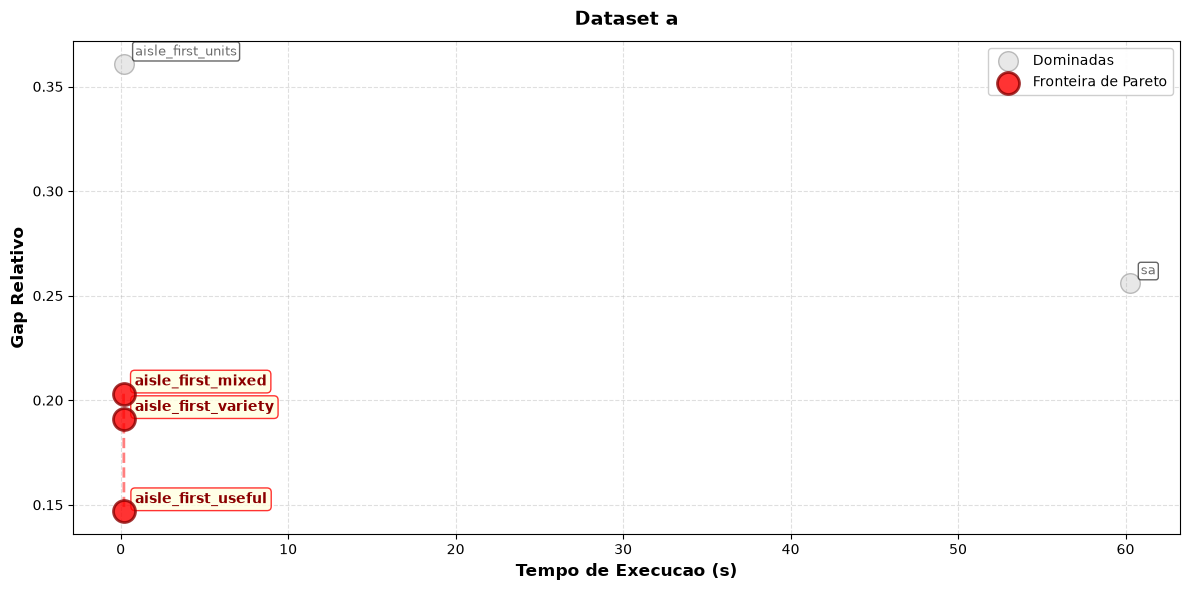

In [7]:
# --- Scatter plot: Pareto frontier por dataset ---
import matplotlib.pyplot as plt

if 'tabela' in locals() and not tabela.empty and 'pareto' in tabela.columns:
    datasets = sorted(tabela['dataset'].unique())
    n_ds = len(datasets)
    fig, axes = plt.subplots(1, n_ds, figsize=(12, 6), squeeze=False)

    for ax, ds in zip(axes[0], datasets):
        sub = tabela[tabela['dataset'] == ds].copy()
        pareto = sub[sub['pareto']]
        dominated = sub[~sub['pareto']]

        ax.scatter(dominated['tempo_media'], dominated['gap_media'],
                   s=200, alpha=0.5, c='lightgray', edgecolors='gray', linewidth=1, label='Dominadas')
        ax.scatter(pareto['tempo_media'], pareto['gap_media'],
                   s=250, alpha=0.8, c='red', edgecolors='darkred', linewidth=2,
                   label='Fronteira de Pareto', zorder=5)

        pareto_sorted = pareto.sort_values('tempo_media')
        ax.plot(pareto_sorted['tempo_media'], pareto_sorted['gap_media'],
                'r--', alpha=0.5, linewidth=2, zorder=4)

        def add_label(row):
            label = row['algo_id']
            if row['pareto']:
                ax.annotate(label, (row['tempo_media'], row['gap_media']),
                            textcoords='offset points', xytext=(8, 6), ha='left',
                            fontsize=10, fontweight='bold', color='darkred',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                                      alpha=0.8, edgecolor='red'))
            else:
                ax.annotate(label, (row['tempo_media'], row['gap_media']),
                            textcoords='offset points', xytext=(8, 6), ha='left',
                            fontsize=9, color='dimgray',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

        sub.apply(add_label, axis=1)

        ax.set_xlabel('Tempo de Execucao (s)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Gap Relativo', fontsize=12, fontweight='bold')
        ax.set_title(f'Dataset {ds}', fontsize=14, fontweight='bold', pad=12)
        ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
        ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    path_png = OUTPUT_DIR / 'pareto_frontier.png'
    fig.savefig(path_png, dpi=150, bbox_inches='tight')
    print('Grafico salvo em:', path_png)
    plt.show()
else:
    print('[INFO] Execute a celula anterior (Pareto frontier) primeiro.')

Algoritmos Pareto: ['aisle_first_useful', 'aisle_first_variety', 'aisle_first_mixed']
Grafico salvo em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/bar_chart_pct_best_pareto.png


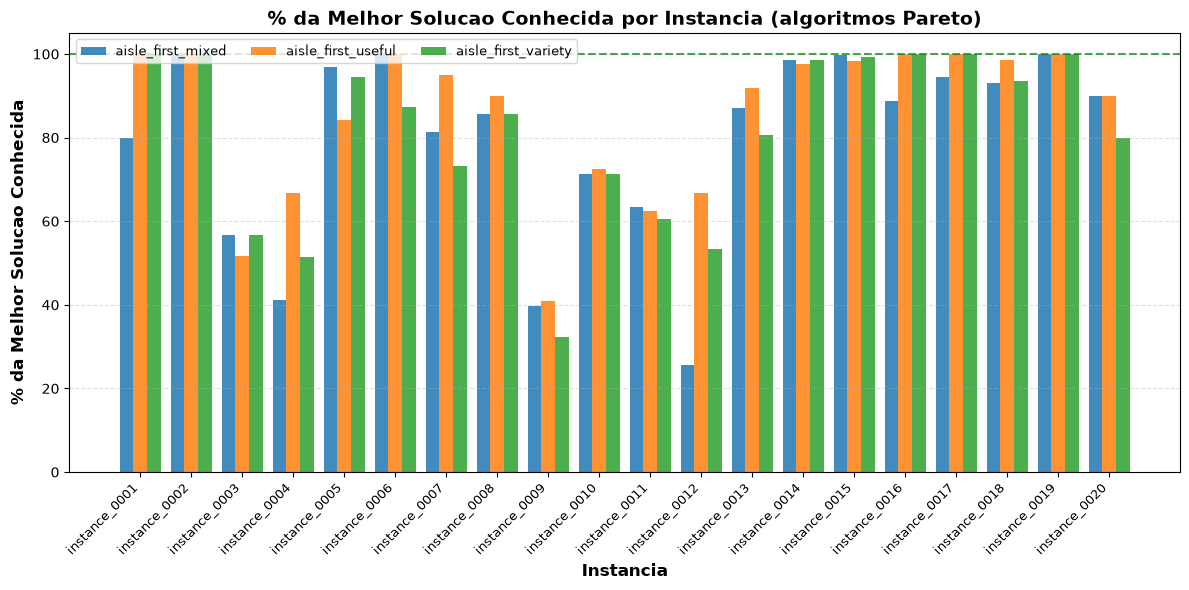

In [8]:
# --- Grafico de Barras: % da melhor solucao conhecida por instancia (apenas Pareto) ---
import matplotlib.pyplot as plt
import numpy as np

if df_ok.empty or 'gap' not in df_ok.columns or 'tabela' not in locals():
    print('[INFO] Execute as celulas anteriores primeiro.')
else:
    pareto_algos = tabela[tabela['pareto']]['algo_id'].unique().tolist()
    print('Algoritmos Pareto:', pareto_algos)

    df_agg = df_ok.groupby(['instance', 'algo_id'], as_index=False)['gap'].mean()
    df_agg['pct_best'] = (1 - df_agg['gap']) * 100
    df_agg = df_agg[df_agg['algo_id'].isin(pareto_algos)]

    pivot = df_agg.pivot(index='instance', columns='algo_id', values='pct_best')
    pivot = pivot.sort_index()

    instances = pivot.index.tolist()
    algos = pivot.columns.tolist()

    x = np.arange(len(instances))
    n_algos = len(algos)
    bar_width = 0.8 / n_algos

    fig, ax = plt.subplots(figsize=(max(12, len(instances) * 0.5), 6))

    for i, algo in enumerate(algos):
        offset = (i - (n_algos - 1) / 2) * bar_width
        values = pivot[algo].values
        ax.bar(x + offset, values, bar_width, label=algo, alpha=0.85)

    ax.set_xlabel('Instancia', fontsize=12, fontweight='bold')
    ax.set_ylabel('% da Melhor Solucao Conhecida', fontsize=12, fontweight='bold')
    ax.set_title('% da Melhor Solucao Conhecida por Instancia (algoritmos Pareto)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(instances, rotation=45, ha='right', fontsize=9)
    ax.legend( fontsize=9, ncol=min(n_algos, 4))
    ax.set_ylim(0, 105)
    ax.axhline(y=100, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='100% (melhor)')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()

    path_png = OUTPUT_DIR / 'bar_chart_pct_best_pareto.png'
    fig.savefig(path_png, dpi=150, bbox_inches='tight')
    print('Grafico salvo em:', path_png)
    plt.show()